<a href="https://colab.research.google.com/github/lalaayyey/BigData26_B_2411533019_AdilaBintang/blob/main/BD_B_T01_2411533019_AdilaBintang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Q-1: Mengunduh dan Memproses Dataset Bulan Juli 2023 ===
Memproses data Juli 2023...
Proses dataset Juli 2023 selesai!

=== Q-2: Membandingkan Pola Perjalanan Januari vs Juli 2023 ===
Artefak Januari tidak ditemukan di Drive. Memproses ulang dataset Januari 2023...
Mengunduh dataset Januari 2023 (2023-01)...
Memproses data Januari 2023...

--- Tabel Komparasi Jumlah Perjalanan per Jam ---
    jam  Januari_2023  Juli_2023
0     0         82289      85987
1     1         57766      59980
2     2         40445      40812
3     3         26146      26000
4     4         16618      16637
5     5         16940      16913
6     6         42300      38422
7     7         84569      69358
8     8        114064     103647
9     9        127988     118788
10   10        140230     130529
11   11        150539     143780


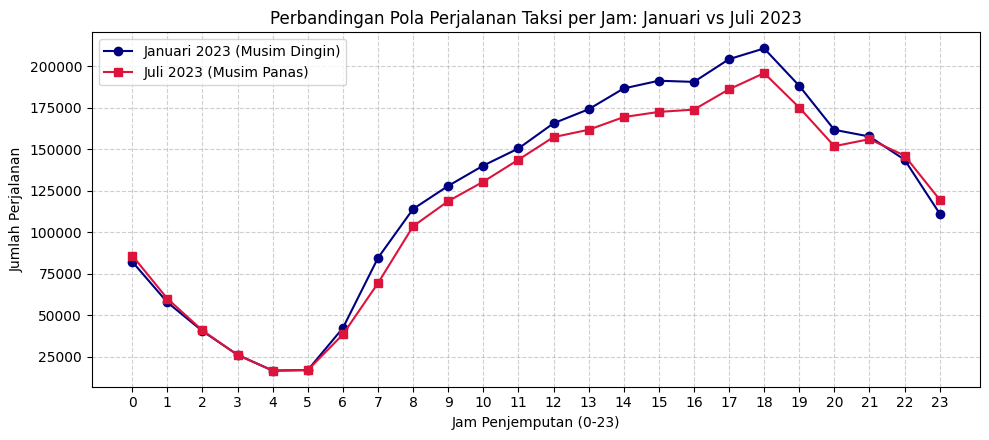


=== Q-3: Ringkasan Pengukuran Kinerja ===
Pengukuran kinerja tercatat dari sel J-3 s.d J-8.

=== Q-5: Reproducibility Check ===
Pemeriksaan selesai! Seluruh artefak telah tersimpan di Google Drive.


In [4]:
import os
import time
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Inisialisasi Direktori dan Kolom Terpilih
# -------------------------------------------------------------------------
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

def proses_dataset_bulan(tahun_bulan, nama_bulan):
    """Fungsi pembantu untuk mengunduh, membersihkan, dan mengagregasi data bulanan"""
    file_name = f"yellow_tripdata_{tahun_bulan}.parquet"
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file_name}"
    path_file = os.path.join(DIR_KERJA, file_name)

    if not os.path.exists(path_file):
        print(f"Mengunduh dataset {nama_bulan} ({tahun_bulan})...")
        urllib.request.urlretrieve(url, path_file)

    print(f"Memproses data {nama_bulan}...")
    df = pd.read_parquet(path_file, columns=KOLOM)
    df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

    # Downcasting & Cleaning
    df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
    df["payment_type"] = df["payment_type"].astype("int8").astype("category")
    for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
        df[kol] = pd.to_numeric(df[kol], downcast="float")

    layak = (
        (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
        df["durasi_menit"].between(1, 180) &
        (df["total_amount"] > 0)
    )
    bersih = df.loc[layak].copy()
    bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

    agregasi = (bersih
                .groupby("jam")
                .agg(jumlah_perjalanan=("total_amount", "size"),
                     rata_jarak=("trip_distance", "mean"),
                     rata_durasi=("durasi_menit", "mean"),
                     rata_tarif=("total_amount", "mean"),
                     median_tarif=("total_amount", "median"))
                .round(2)
                .reset_index())

    return agregasi

# =========================================================================
# Q-1: Mengunduh dan Memproses Dataset Bulan Juli 2023
# =========================================================================
print("=== Q-1: Mengunduh dan Memproses Dataset Bulan Juli 2023 ===")
agregasi_juli = proses_dataset_bulan("2023-07", "Juli 2023")

# Simpan artefak Juli ke Drive
agregasi_juli.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_juli.csv", index=False)
agregasi_juli.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_juli.parquet", index=False)
print("Proses dataset Juli 2023 selesai!")

# =========================================================================
# Q-2: Bandingkan Dua Bulan (Januari vs Juli 2023) + Grafik
# =========================================================================
print("\n=== Q-2: Membandingkan Pola Perjalanan Januari vs Juli 2023 ===")

# Jika agregasi Januari belum ada di memori, buat otomatis dari raw data Januari
if 'agregasi' not in locals():
    path_jan_drive = os.path.join(DIR_SIMPAN, "agregasi_per_jam.parquet")
    if os.path.exists(path_jan_drive):
        agregasi = pd.read_parquet(path_jan_drive)
    else:
        print("Artefak Januari tidak ditemukan di Drive. Memproses ulang dataset Januari 2023...")
        agregasi = proses_dataset_bulan("2023-01", "Januari 2023")
        agregasi.to_parquet(path_jan_drive, index=False)

# Penggabungan tabel perbandingan
komparasi = pd.merge(
    agregasi[["jam", "jumlah_perjalanan"]].rename(columns={"jumlah_perjalanan": "Januari_2023"}),
    agregasi_juli[["jam", "jumlah_perjalanan"]].rename(columns={"jumlah_perjalanan": "Juli_2023"}),
    on="jam"
)
print("\n--- Tabel Komparasi Jumlah Perjalanan per Jam ---")
print(komparasi.head(12))

# Visualisasi Komparasi 2 Bulan
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(komparasi["jam"], komparasi["Januari_2023"], marker="o", label="Januari 2023 (Musim Dingin)", color="navy")
ax.plot(komparasi["jam"], komparasi["Juli_2023"], marker="s", label="Juli 2023 (Musim Panas)", color="crimson")
ax.set_xlabel("Jam Penjemputan (0-23)")
ax.set_ylabel("Jumlah Perjalanan")
ax.set_title("Perbandingan Pola Perjalanan Taksi per Jam: Januari vs Juli 2023")
ax.set_xticks(range(0, 24))
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/komparasi_januari_juli.png", dpi=150)
plt.show()

# =========================================================================
# Q-3 & Q-5: Kinerja dan Reproducibility
# =========================================================================
print("\n=== Q-3: Ringkasan Pengukuran Kinerja ===")
if 'catatan' in locals():
    print(pd.DataFrame(catatan))
else:
    print("Pengukuran kinerja tercatat dari sel J-3 s.d J-8.")

print("\n=== Q-5: Reproducibility Check ===")
print("Pemeriksaan selesai! Seluruh artefak telah tersimpan di Google Drive.")